<a href="https://colab.research.google.com/github/jeankonan748/breast-cancer-prediction-bigdata/blob/main/ml_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PHASE 1 — INITIALISATION DU PROJET

Importation des bibliothèques

In [1]:
# Manipulation de données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Prétraitement
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV

# Modèles ML
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Évaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report


Chargement du Dataset

In [2]:
import os

In [3]:
from google.colab import drive
drive.mount('/gdrive')

Mounted at /gdrive


In [4]:
with open('/gdrive/My Drive/foo.txt', 'w') as f:
  f.write('Hello Google Drive!')
!cat '/gdrive/My Drive/foo.txt'

Hello Google Drive!

In [5]:
os.listdir('/gdrive/My Drive/Soutenance M2 ML DL')

['dataset']

In [6]:
os.listdir('/gdrive/My Drive/Soutenance M2 ML DL/dataset')

['breast-cancer.csv', 'BreastCancer_Benign.zip', 'BreastCancer_Malignant.zip']

In [7]:
data = pd.read_csv('/gdrive/My Drive/Soutenance M2 ML DL/dataset/breast-cancer.csv')
data

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [8]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**📌 Analyse Exploratoire Rapide**

In [9]:
print(data.shape)

(569, 32)


In [10]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [11]:
print(data.describe())

                 id  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813     

Vérification des classes

In [12]:
data['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


In [13]:
#Convertir la variable cible :
data['diagnosis'] = data['diagnosis'].map({'B': 0, 'M': 1})

📌Séparation des Variables

In [14]:
X = data.drop(['diagnosis', 'id'], axis=1)
y = data['diagnosis']

In [15]:
y.value_counts()

,count
diagnosis,
0,357
1,212


Normalisation

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Split Train / Test

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# PHASE 2 — CROSS VALIDATION (K-FOLD)

In [18]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=kfold, scoring='accuracy')
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

Logistic Regression: 0.9771 (+/- 0.0090)
SVM: 0.9789 (+/- 0.0071)
Random Forest: 0.9596 (+/- 0.0090)
KNN: 0.9595 (+/- 0.0191)


⚙️ PHASE 3 — GRIDSEARCH OPTIMIZATION

🔹 Random Forest Optimisé

In [19]:
param_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(RandomForestClassifier(), param_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)

print("Best RF Parameters:", grid_rf.best_params_)

Best RF Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}


🔹 SVM Optimisé

In [20]:
param_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf']
}

grid_svm = GridSearchCV(SVC(probability=True), param_svm, cv=5, scoring='accuracy')
grid_svm.fit(X_train, y_train)

print("Best SVM Parameters:", grid_svm.best_params_)

Best SVM Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


📊 **PHASE 4 — ÉVALUATION FINALE**


In [21]:
def evaluate_model(model):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("AUC:", roc_auc_score(y_test, y_prob))

    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

In [24]:
evaluate_model(grid_rf.best_estimator_)

Accuracy: 0.9649122807017544
Precision: 0.975609756097561
Recall: 0.9302325581395349
F1 Score: 0.9523809523809523
AUC: 0.9950867998689814

Confusion Matrix:
 [[70  1]
 [ 3 40]]


**Évaluer Random Forest Optimisé**

In [25]:
best_rf = grid_rf.best_estimator_
evaluate_model(best_rf)

Accuracy: 0.9649122807017544
Precision: 0.975609756097561
Recall: 0.9302325581395349
F1 Score: 0.9523809523809523
AUC: 0.9950867998689814

Confusion Matrix:
 [[70  1]
 [ 3 40]]


Évaluer SVM Optimisé

In [26]:
best_svm = grid_svm.best_estimator_
evaluate_model(best_svm)

Accuracy: 0.9736842105263158
Precision: 0.9761904761904762
Recall: 0.9534883720930233
F1 Score: 0.9647058823529412
AUC: 0.99737962659679

Confusion Matrix:
 [[70  1]
 [ 2 41]]


**📈 PHASE 5 — FEATURE IMPORTANCE**

In [28]:
importances = best_rf.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head(10))

                 Feature  Importance
22       perimeter_worst    0.121697
27  concave points_worst    0.120646
20          radius_worst    0.103757
7    concave points_mean    0.101212
23            area_worst    0.099202
6         concavity_mean    0.050300
2         perimeter_mean    0.049995
3              area_mean    0.047040
0            radius_mean    0.046204
26       concavity_worst    0.045730


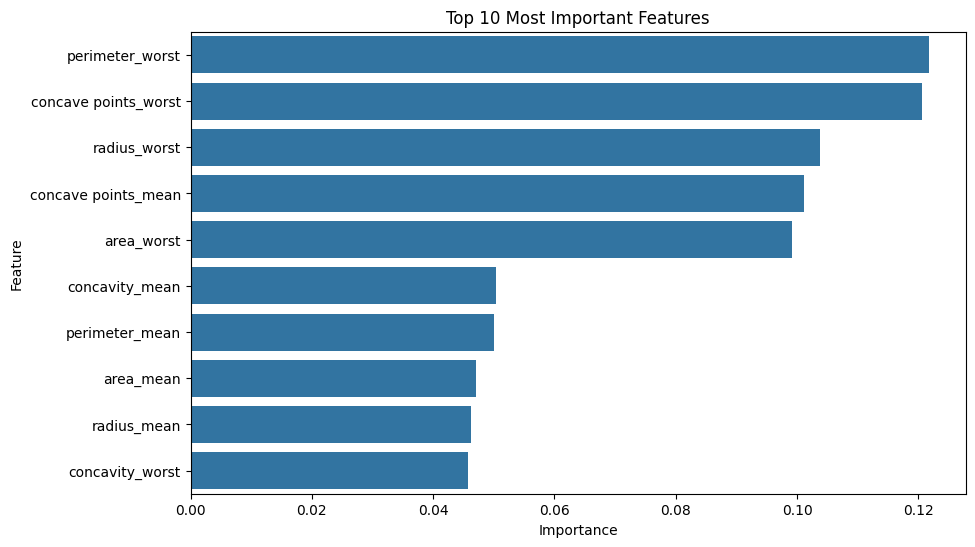

In [29]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title("Top 10 Most Important Features")
plt.show()

**🧠 PHASE 6 — EXPLICABILITÉ AVEC SHAP**

📌Importation de SHAP

In [33]:
import shap

AttributeError: module 'numba.core.types' has no attribute 'misc'

In [ ]:
shap.initjs()

📌 Création de l’Explainer

On utilise le modèle optimisé :

In [ ]:
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

In [ ]:
print(f"Shape of shap_values: {shap_values.shape}")

In [ ]:
print(f"Shape of X_test_df: {X_test_df.shape}")

In [ ]:
X_test_df = pd.DataFrame(X_test, columns=X.columns)
shap.summary_plot(shap_values[:, :, 1], X_test_df, feature_names=X.columns)

In [ ]:
shap.summary_plot(shap_values[:, :, 1], X_test_df, feature_names=X.columns, plot_type="bar")

In [ ]:
shap.force_plot(
    explainer.expected_value[1],
    shap_values[0, :, 1],
    X_test[0],
    feature_names=X.columns
)

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[1][0],
        base_values=explainer.expected_value[1],
        data=X_test[0],
        feature_names=X.columns
    )
)

**PHASE 7 — DEEP LEARNING (ANN)**

📌 1️⃣ Installation des bibliothèques

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

📌Construction du modèle ANN

Notre dataset possède 30 variables, donc :

Input layer = 30 neurones

In [ ]:
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

📌Compilation du modèle

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

📌 5️⃣ Early Stopping (éviter l’overfitting)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

📌 6️⃣ Entraînement du modèle

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

📊 7️⃣ Évaluation du modèle

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

📊 8️⃣ Prédictions

In [ ]:
y_pred_dl = model.predict(X_test)
y_pred_dl = (y_pred_dl > 0.5).astype(int)

📊 9️⃣ Métriques

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_dl))
print("Precision:", precision_score(y_test, y_pred_dl))
print("Recall:", recall_score(y_test, y_pred_dl))
print("F1-score:", f1_score(y_test, y_pred_dl))

📊 Matrice de confusion

In [ ]:
cm = confusion_matrix(y_test, y_pred_dl)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Deep Learning")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

📈 10️⃣ Courbes d’apprentissage

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(['train', 'validation'])
plt.show()

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.legend(['train', 'validation'])
plt.show()